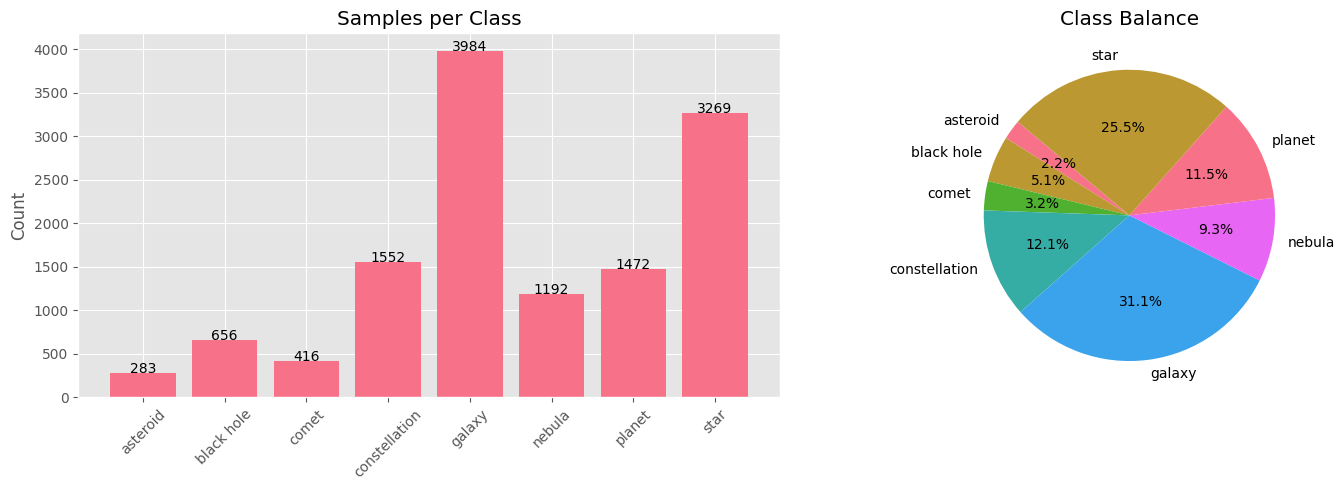

Total: 12,824 images | Imbalance (max/min): 14.1x
Could not load asteroid: [WinError 123] The filename, directory name, or volume label syntax is incorrect: 'kagglehub.dataset_download("razaimam45/spacenet-an-optimally-distributed-astronomy-data\\asteroid'
Could not load black hole: [WinError 123] The filename, directory name, or volume label syntax is incorrect: 'kagglehub.dataset_download("razaimam45/spacenet-an-optimally-distributed-astronomy-data\\black hole'
Sample Resolutions: []
Sample Formats: []


In [9]:
import pandas as pd, matplotlib.pyplot as plt, os
from PIL import Image

# Dataset classes and counts from Kaggle page
classes = ['asteroid', 'black hole', 'comet', 'constellation', 'galaxy', 'nebula', 'planet', 'star']
counts = [283, 656, 416, 1552, 3984, 1192, 1472, 3269]

# 1. Plot Class Distribution
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
bars = plt.bar(classes, counts); plt.xticks(rotation=45)
[plt.text(b.get_x()+b.get_width()/2, b.get_height(), str(c), ha='center') for b,c in zip(bars, counts)]
plt.title('Samples per Class'); plt.ylabel('Count')
plt.subplot(1,2,2)
plt.pie(counts, labels=classes, autopct='%1.1f%%', startangle=140)
plt.title('Class Balance'); plt.tight_layout(); plt.show()
print(f"Total: {sum(counts):,} images | Imbalance (max/min): {max(counts)/min(counts):.1f}x")

# 2. Setup for Sample Visualization & Analysis
base_path = 'kagglehub.dataset_download("razaimam45/spacenet-an-optimally-distributed-astronomy-data'
resolutions, formats = [], []
for cls in classes[:2]: # Analyze first 2 classes only for brevity
    cls_path = os.path.join(base_path, cls)
    try:
        img_files = [f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.png', '.jpeg'))][:1] # Get 1 image
        for img_file in img_files:
            with Image.open(os.path.join(cls_path, img_file)) as img:
                plt.imshow(img); plt.title(f'Sample: {cls}'); plt.axis('off'); plt.show()
                resolutions.append(img.size); formats.append(img.format or 'Unknown')
    except Exception as e: print(f"Could not load {cls}: {e}")
print(f"Sample Resolutions: {resolutions}\nSample Formats: {formats}")